# PEC1: Tipología y fuentes de datos

# Enunciado 4: Conversión de DataFrame a JSON y análisis (1 punto)

En este ejercicio, a partir de un DataFrame con información de clientes y compras, lo convertirás a formato JSON y realizarás un análisis sobre la estructura y contenido del archivo JSON generado.

**Objetivos:**
- Convertir el DataFrame a formato JSON (orientación por archivo o por registro).
- Analizar la estructura del JSON resultante: cuántas entradas tiene, qué campos hay, si hay valores nulos, etc.
- Cargar el JSON de nuevo y compararlo con el original para validar la conversión.

**Instrucciones:**
1. Convierte el DataFrame a JSON y guárdalo en un archivo.
2. Lee el archivo JSON y muestra su estructura (claves, número de entradas, ejemplos).
3. Comprueba si hay valores nulos o campos vacíos en el JSON.
4. Comenta posibles ventajas e inconvenientes de trabajar con datos en formato JSON vs DataFrame.


**Solución:**

In [1]:
# Crear un DataFrame ficticio de 50 filas con información de clientes y compras
import pandas as pd
import numpy as np
np.random.seed(42)
n = 50
df = pd.DataFrame({
    'id_cliente': np.arange(1, n+1),
    'nombre': np.random.choice(['Ana', 'Juan', 'María', 'Pablo', 'Laura', 'Marcos', 'Jorge', 'Clara'], n),
    'pais': np.random.choice(['ES', 'PT', 'FR', 'IT'], n),
    'producto': np.random.choice(['Libro', 'Bolígrafo', 'Cuaderno', 'Mochila'], n),
    'cantidad': np.random.randint(1, 10, n),
    'precio_unitario': np.round(np.random.uniform(1.0, 30.0, n), 2),
    'fecha_compra': pd.to_datetime('2026-01-01') + pd.to_timedelta(np.random.randint(0, 30, n), unit='D')
})
df['importe_total'] = df['cantidad'] * df['precio_unitario']
df.head()

,id_cliente,nombre,pais,producto,cantidad,precio_unitario,fecha_compra,importe_total
0,1,Jorge,FR,Cuaderno,3,7.61,2026-01-07,22.83
1,2,Pablo,PT,Bolígrafo,3,13.39,2026-01-20,40.17
2,3,Laura,FR,Bolígrafo,1,24.72,2026-01-09,24.72
3,4,Jorge,IT,Mochila,5,25.96,2026-01-01,129.80
4,5,María,FR,Bolígrafo,7,1.20,2026-01-08,8.40


1. Convierte el DataFrame a JSON y guárdalo en un archivo.

In [2]:
import json #importamos la biblioteca JSON

df.to_json("data.json", orient="records") #conversión a json por registro y guardado en el archivo data.json
data =pd.read_json("data.json") #lectura del archivo json

2. Lee el archivo JSON y muestra su estructura (claves, número de entradas, ejemplos).

In [3]:
data =pd.read_json("data.json") #lectura del archivo json
#data.head()
data.info() #entradas, columna, datos, valores nulos etc
data.shape #50 filas por 8 columnas
print("numero de entradas es:",len(data), "los ids son:",data.keys(), " ") #realizamos un print con lo solicitado
data.head(3) #head de 3 filas
print(data[:3]) #con la estgructura de json

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_cliente       50 non-null     int64  
 1   nombre           50 non-null     object 
 2   pais             50 non-null     object 
 3   producto         50 non-null     object 
 4   cantidad         50 non-null     int64  
 5   precio_unitario  50 non-null     float64
 6   fecha_compra     50 non-null     int64  
 7   importe_total    50 non-null     float64
dtypes: float64(2), int64(3), object(3)
memory usage: 3.3+ KB
numero de entradas es: 50 los ids son: Index(['id_cliente', 'nombre', 'pais', 'producto', 'cantidad',
       'precio_unitario', 'fecha_compra', 'importe_total'],
      dtype='object')  
   id_cliente nombre pais   producto  cantidad  precio_unitario  \
0           1  Jorge   FR   Cuaderno         3             7.61   
1           2  Pablo   PT  Bolígrafo         3          

3. Comprueba si hay valores nulos o campos vacíos en el JSON.



In [4]:
data.isna().sum() #sin valores vacios o nulos

,0
id_cliente,0
nombre,0
pais,0
producto,0
cantidad,0
precio_unitario,0
fecha_compra,0
importe_total,0


4. Comenta posibles ventajas e inconvenientes de trabajar con datos en formato JSON vs DataFrame.

**Ventajas Json vs Dataframe**: formato tipo diccionario que se puede usar sin bibliotecas y con código básico de pyhton, parecido xml independiente del lenguaje de programación, más libiano y jerárquico.
**Desventajas Json vs Dataframe**: peor para análisis de datos ya que no puedes caclular medias ni nada parecido de estadística (pandas lo convierte automáticamente en dataframe),menos eficiente para estadística y en general no está hecho para graficar o convertir los datos de una manera eficiente.

# Enunciado 5: Metadatos de imagen (2 puntos)

En este ejercicio trabajarás con una imagen real descargada de internet para analizar sus metadatos y características básicas. El objetivo es entender cómo se pueden extraer e interpretar atributos técnicos y contextuales de una imagen digital, como el formato, el tamaño, el modo de color, la información EXIF (fecha, dispositivo, cámara), la distribución de colores y la posible geolocalización.

**Instrucciones:**
1. ¿Cuál es el formato, el tamaño (dimensiones) y el modo de color de la imagen?
2. ¿Qué información EXIF contiene la imagen? (Fecha de creación, dispositivo, configuración de cámara…)
3. ¿Cuál es la distribución de los colores principales en la imagen? (Histograma de colores)
4. ¿La imagen contiene información de geolocalización (latitud/longitud) en los metadatos?
5. ¿Cuál es la relación de aspecto (ancho/alto) y cómo afecta a la visualización de la imagen?


In [5]:
from PIL import Image
import requests
from io import BytesIO
import os
import matplotlib.pyplot as plt
import numpy as np


img_url = 'https://upload.wikimedia.org/wikipedia/commons/a/a6/Evening_light_over_Barcelona.jpg'
img_path = 'barcelona.jpg'

headers = {'User-Agent': 'Mozilla/5.0'}
if not os.path.exists(img_path):
    r = requests.get(img_url, headers=headers, stream=True)
    if r.status_code == 200:
        with open(img_path, 'wb') as f:
            for chunk in r.iter_content(1024):
                f.write(chunk)
    else:
        raise Exception(f'No se ha podido descargar la imagen. Código de estado: {r.status_code}')

img = Image.open(img_path)
print(img)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=5995x2799 at 0x7AA1C1C9B2C0>


A partir de la imagen anterior, resuelve los siguientes apartados:
1. ¿Cuál es el formato, el tamaño (dimensiones) y el modo de color de la imagen?

In [6]:
print("Formato:", img.format) #obtenemos el tipo de formato de imamgen
print("Tamaño", img.size) #obtenemos las dimensiones de la imagen
print("Color de la imagen", img.mode) #el tipo de color de la imagen
print("El formato de la imagen es",img.format, "con dimensiones", img.size,"y color de la imagen",img.mode)

Formato: JPEG
Tamaño (5995, 2799)
Color de la imagen RGB
El formato de la imagen es JPEG con dimensiones (5995, 2799) y color de la imagen RGB


2. ¿Qué información EXIF contiene la imagen? (Fecha de creación, dispositivo, configuración de cámara…)

In [7]:
#fuente: https://www.jesusninoc.com/05/04/mostrar-datos-exif-de-una-imagen-en-python/
exif_data = img._getexif()

for tag, value in exif_data.items():
  print("Propiedad->", value,"codigo->", tag)

#podemos comprobar que contiene muchisimo tipo de información.
#el fabricante de la cámara (Nikon Corporation) y el modelo (Nikon D7100) También aparece la fecha de captura (2015-10-08 18:23:56) y otra fecha asociada del archivo (2020-02-21)
#tiempo de exposición (1/350 s), apertura (f/5.6), valor ISO (200) y la distancia focal (50 mm)
#resolución de la imagen etc

Propiedad-> {0: b'\x02\x03\x00\x00'} codigo-> 34853
Propiedad-> 2 codigo-> 296
Propiedad-> 339 codigo-> 34665
Propiedad-> NIKON CORPORATION codigo-> 271
Propiedad-> NIKON D7100 codigo-> 272
Propiedad-> Ver.1.00  codigo-> 305
Propiedad-> 1 codigo-> 274
Propiedad-> 2020:02:21 12:01:31  codigo-> 306
Propiedad-> 2 codigo-> 531
Propiedad-> 300.0 codigo-> 283
Propiedad->                                                        codigo-> 33432
Propiedad-> 300.0 codigo-> 282
Propiedad->                                      codigo-> 315
Propiedad-> b'0230' codigo-> 36864
Propiedad-> b'\x01\x02\x03\x00' codigo-> 37121
Propiedad-> 4.0 codigo-> 37122
Propiedad-> 2015:10:08 18:23:56  codigo-> 36867
Propiedad-> 2015:10:08 18:23:56  codigo-> 36868
Propiedad-> 0.0 codigo-> 37380
Propiedad-> 0.0 codigo-> 37381
Propiedad-> 2 codigo-> 37383
Propiedad-> 0 codigo-> 37384
Propiedad-> 16 codigo-> 37385
Propiedad-> 50.0 codigo-> 37386
Propiedad-> b'ASCII\x00\x00\x00                                    ' codigo-> 

3. ¿Cuál es la distribución de los colores principales en la imagen? (Histograma de colores)

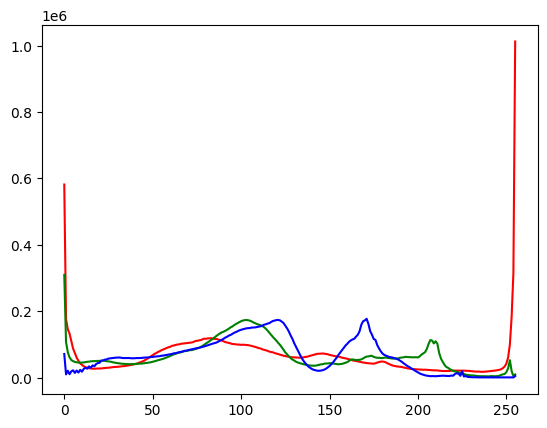

In [8]:
hist=img.histogram()
#separamos por sus colores RGB
r=hist[0:256]
g=hist[256:512]
b=hist[512:768]

#ploteamos
plt.plot(r, color="red")
plt.plot(g, color="green")
plt.plot(b, color="blue")
plt.show()

# Se ha separado el histograma en 3 intervalos a los canales RGB
# (rojo, verde y azul) y se han representado gráficamente.
# Los gráficos muestran la cantidad de píxeles para cada nivel de intensidad de color.
# Si uno de los canales presenta valores más altos, significa que ese color tiene mayor presencia en la imagen.

4. ¿La imagen contiene información de geolocalización (latitud/longitud) en los metadatos?

In [9]:
#https://exiftool.org/TagNames/GPS.html https://pillow.readthedocs.io/en/stable/reference/ExifTags.html
exif_data = img._getexif()

if exif_data and 34853 in exif_data:
    print("Contiene información de geolocalización:",exif_data[34853])
else:
    print("No hay información de geolocalización")

#se obtiene el tag correspondiente a GPS con los datos de geolocalización.
#el campo no tiene datos de latitud ni longitud pero sí contiene los datos de geolocalizacion {0: b'\x02\x03\x00\x00'}

Contiene información de geolocalización: {0: b'\x02\x03\x00\x00'}


5. ¿Cuál es la relación de aspecto (ancho/alto) y cómo afecta a la visualización de la imagen?

In [11]:
aspect_ratio =img.width / img.height
print("Relación de aspecto:", aspect_ratio)
#relacion de aspecto es la proporción entre el ancho y el alto de la imagen.
#puede afectar que depende el tipo de periférico no se vea como toca.
#mantener la poporción es necesario para mantener la imagen original.

Relación de aspecto: 2.14183637013219


**Solución:**

# Enunciado 6: De datos no estructurados (audio MP3) a estructurados (2 puntos)

En este ejercicio, trabajaremos con un archivo de audio (mp3) para extraer características y convertirlas en un DataFrame estructurado. El objetivo es mostrar cómo se pueden transformar datos no estructurados en información analizable.

**Instrucciones:**
1. Descarga un archivo mp3 de ejemplo (o utiliza un archivo local si ya lo tienes).
2. Carga el audio y extrae características básicas: duración, número de canales, frecuencia de muestreo, etc.
3. Calcula características adicionales: energía media, zero crossing rate, espectro de frecuencias, etc.
4. Organiza estas características en un DataFrame (una fila por archivo).
5. Comenta cómo estas características pueden ser útiles para clasificación o análisis de audio.

Las características extraídas (duración, energía, zero crossing rate, espectro, etc.) permiten transformar un archivo de audio no estructurado en datos estructurados, facilitando su análisis cuantitativo. Estas variables son útiles para tareas de clasificación de audio, detección de eventos, reconocimiento de voz o música, y para la descripción automática de contenido multimedia.

**Solución:**

In [18]:
mp3_url = 'https://upload.wikimedia.org/wikipedia/commons/4/4d/Singin%27_in_the_Rain.mp3'

1. Descarga un archivo mp3 de ejemplo (o utiliza un archivo local si ya lo tienes).

In [19]:
from google.colab import drive #accedo a mi drive

drive.mount('/content/drive') #monto el driver
!ls "/content/drive/MyDrive/Tipologia y fuentes de datos/Musica"  # reviso que el fichero se encuentre ahí
file = "/content/drive/MyDrive/Tipologia y fuentes de datos/Musica/Singin'_in_the_Rain.mp3" #añado a una variable del file

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
"Singin'_in_the_Rain.mp3"


2. Carga el audio y extrae características básicas: duración, número de canales, frecuencia de muestreo, etc.

In [20]:
import librosa
import numpy as np
import pandas as pd

y, sr = librosa.load(file) #cargamos el audio
channels =y.ndim #determina la cantidad de canales
duration = librosa.get_duration(y=y, sr=sr) #duracion total del audio

print("Frecuencia de muestreo:", sr, "Número de canales:", channels, "Duracion:", duration)
#https://librosa.org/doc/latest/generated/librosa.load.html


Frecuencia de muestreo: 22050 Número de canales: 1 Duracion: 39.372743764172334


3. Calcula características adicionales: energía media, zero crossing rate, espectro de frecuencias, etc.

In [21]:
#https://joserzapata.github.io/courses/mineria-audio1/extraccion_caracteristicas/
energy = np.mean(y**2)
zcr =np.mean(librosa.feature.zero_crossing_rate(y)) #zerop crossing rate
spectral_centroid =np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))#espectro de frecuencias
spectral_bandwidth =np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)) #ancho de banda

print("Energía media:", energy, "zero crossing", zcr, "ancho de banda",spectral_bandwidth,"centroide", spectral_centroid)

#se calculan caracteristicas del audio como la energia media, el zero crossing, espectro de frecuencias, centroide etc


Energía media: 0.010331814 zero crossing 0.08756472029775944 ancho de banda 1412.8221683692063 centroide 1564.2444822559223


4. Organiza estas características en un DataFrame

In [22]:
df = pd.DataFrame({
    "duracion": [duration],"canales": [channels],"frecuencia_muestreo": [sr],"energia_media": [energy],"zero_crossing_rate": [zcr],"spectral_centroid": [spectral_centroid]
})

df.head()

,duracion,canales,frecuencia_muestreo,energia_media,zero_crossing_rate,spectral_centroid
0,39.372744,1,22050,0.010332,0.087565,1564.244482


5. Comenta cómo estas características pueden ser útiles para clasificación o análisis de audio.

Se sacan características de todo tipo del audio. Son útiles para poder clasificar el audio por sus propiedades. Energia media, zero crossing, ancho de banda, centroide...  Otras características como la duración, el número de canales o la frecuencea de muestreo aportan información técnica del audio. Podrían permitir ciertos modelos de cluster como k-means cluster para encontrar patrones entre diferentes canciones. Modelos supervisados como arboles de decision o random forest para clasificar.

# Enunciado 7: (2 puntos)

Ejercicio abierto de análisis de datos en Python

#### Objetivo
El objetivo de este ejercicio es buscar un conjunto de datos en formato CSV, importarlo como DataFrame en Pandas y realizar un análisis gráfico y estadístico con varias visualizaciones.

#### Instrucciones
Busca un archivo CSV:

* Encuentra un conjunto de datos en formato .csv. Puedes buscar en portales como Kaggle, data.gov u otros repositorios de datos abiertos.
* Asegúrate de que contenga variables numéricas y categóricas para poder hacer diferentes tipos de gráficos.
* Cárgalo en un DataFrame con pandas.read_csv().

##### Tareas a realizar:

1. Visualización Boxplot
* Haz un boxplot de una variable numérica relevante para visualizar su distribución y la presencia de valores atípicos.
* Explica qué puedes interpretar a partir del gráfico.

2. Visualización Barplot
* Haz un gráfico de barras para comparar categorías de una variable cualitativa con una numérica.
* ¿Qué diferencias observas entre las categorías?

3. Visualización Scatterplot
* Representa la relación entre dos variables numéricas mediante un gráfico de dispersión.
* ¿Hay alguna correlación entre las variables? Coméntalo.

4. Regresión lineal
* Calcula la regresión lineal entre dos variables numéricas y muestra la recta de regresión.
* Muestra la ecuación de la recta y el valor de R².
* ¿La regresión es significativa? Explícalo.

5. Visualización Gráfico libre
* Elige cualquier otro tipo de visualización que consideres relevante para explorar mejor los datos (histograma, heatmap, pie chart, etc.).
* Justifica por qué la has elegido y qué aporta al análisis.

6. Conclusiones: resume los principales hallazgos del análisis.
* ¿Hay patrones interesantes en los datos?
* ¿Hay algún dato que te llame la atención o que necesite más investigación?

In [23]:
#Montamos drive y vamos a la carpeta que toca para acceder al csv
from google.colab import drive #accedo a mi drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive') #monto el driver
!ls "/content/drive/MyDrive/Tipologia y fuentes de datos/datasets"  # reviso que el fichero se encuentre ahí
file = "/content/drive/MyDrive/Tipologia y fuentes de datos/datasets/ufc_fighters.csv" #añado a una variable del file
df = pd.read_csv(file)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ufc_fighters.csv


,First Name,Last Name,Nickname,Height,Weight,Reach,Stance,Wins,Losses,Draws
0,Tom,Aaron,NaN,--,155 lbs.,--,NaN,5,3,0
1,Danny,Abbadi,The Assassin,"5' 11""",155 lbs.,--,Orthodox,4,6,0
2,Nariman,Abbasov,Bayraktar,"5' 8""",155 lbs.,"66.0""",Orthodox,28,4,0
3,David,Abbott,Tank,"6' 0""",265 lbs.,--,Switch,10,15,0
4,Hamdy,Abdelwahab,The Hammer,"6' 2""",264 lbs.,"72.0""",Southpaw,5,0,0


**Visualización Boxplot**

1.   Haz un boxplot de una variable numérica relevante para visualizar su distribución y la presencia de valores atípicos
2.   Explica qué puedes interpretar a partir del gráfico.


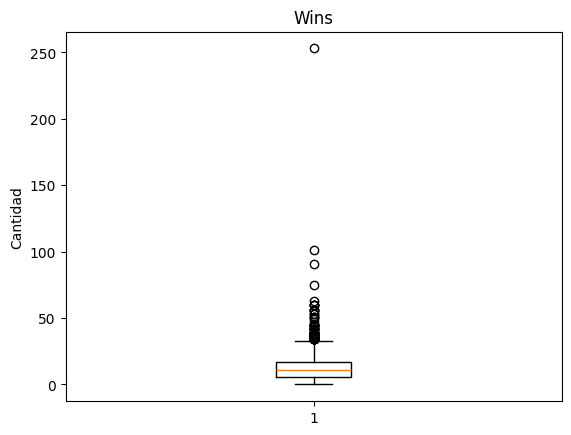

In [24]:
plt.boxplot(df["Wins"])
plt.title("Wins")
plt.ylabel("Cantidad")
plt.show()
#Vemos una distribución con un outlier bastante dominante. La mediana está cercana a 10 victorias y la mayoría de observaciones están entre 5 y 15 victoriass. Comprobamos que obviamente
#la distribución no tiene valores por debajo de cero debido a que no puede existir victorias negativas (por lo menos en el valor absoluto de la palabra)
#los puntos que aparecen fuera de los límites del boxplot sugieren q existen algunos luchadores con un número de victorias significativamente altos a la mayoría.

**Visualización Barplot**

1.   Haz un gráfico de barras para comparar categorías de una variable cualitativa con una numérica.

2.   ¿Qué diferencias observas entre las categorías?


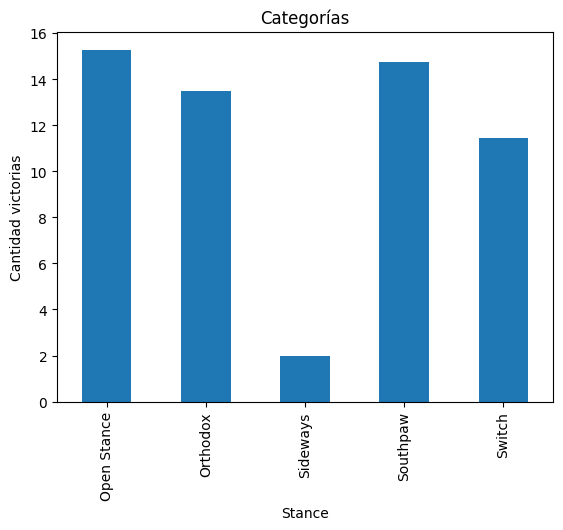

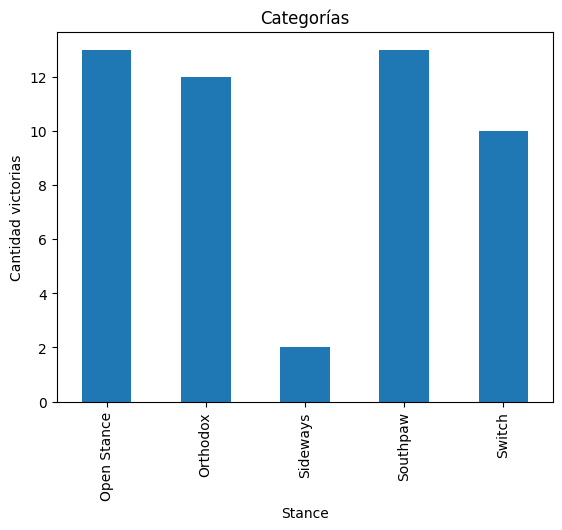

In [25]:
Wins_Stance =df.groupby("Stance")["Wins"].mean()
Wins_Stance.plot(kind="bar")
plt.title("Categorías")
plt.ylabel("Cantidad victorias")
plt.show()
#Organizamos el número de victorias por categoría "stance"
#Podemos observar que las categorías son similares entre ellas y la media está entre (12,15) excepto "sideways" que apenas llega al 2 de media.

Wins_Stance =df.groupby("Stance")["Wins"].median()
Wins_Stance.plot(kind="bar")
plt.title("Categorías")
plt.ylabel("Cantidad victorias")
plt.show()

#Podemos comprobar que la mediana está bastante cerca de la media.

**Visualización Scatterplot**

1.   Representa la relación entre dos variables numéricas mediante un gráfico de dispersión.
2.   ¿Hay alguna correlación entre las variables? Coméntalo.



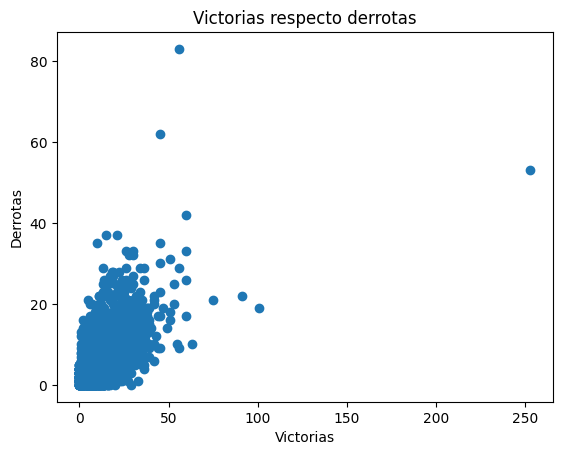

,Wins,Losses
Wins,1.000000,0.623423
Losses,0.623423,1.000000


In [26]:
plt.scatter(df["Wins"], df["Losses"])
plt.xlabel("Victorias")
plt.ylabel("Derrotas")
plt.title("Victorias respecto derrotas")
plt.show()
df[["Wins", "Losses"]].corr()


#Valor cercano a 0.6 por lo que existe una correlación moderada
#Podemos comprobar que hay ciertra dispersión y que la mayoría de puntos se concentran entre 0 y 40.
#Debido a que depende de los combates totales hay cierta relación. Muchos combates implica muchas derrotads y



**Regresión lineal**

1.   Calcula la regresión lineal entre dos variables numéricas y muestra la recta de regresión.

2.   Muestra la ecuación de la recta y el valor de R².
¿La regresión es significativa? Explícalo.



La pendiente es: 0.3387065521652361 el intercepto es: 1.5838108981036099 calidad del ajuste es: 0.3886565384369166
Con un r2 de 0.3887 la relacion es debil ya que explicamos alrededor 38.9 % de la variabilidad de los datos
Con un valor de 0.3887 la regresión es significativa pero poco significativa. Los valores están dentro de la tendencia media, ya que existe relación entre victorias y derrotas, el modelo solo explica parte de la variabilidad de los datos


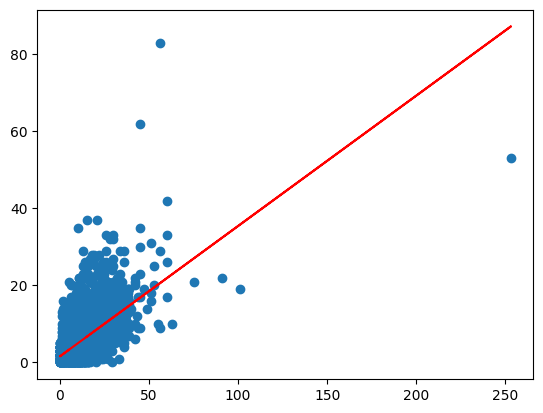

In [27]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

#modelo
X = df[["Wins"]] #variable independiente
Y = df["Losses"] #variable a predecir
model = LinearRegression() #creamos el modelo de regresión lineal (y=ax+b)
model.fit(X, Y) #entrenamos el modelo con los datos que tenemos
y_pred = model.predict(X) #modelo de predicción.

#Coeficientes
a =model.coef_[0] #pendiente
b =model.intercept_ #intecepto
r2 =r2_score(Y, y_pred) #r2 calidad del ajuste
print("La pendiente es:",a, "el intercepto es:", b, "calidad del ajuste es:", r2)
print("Con un r2 de",round(r2,4),"la relacion es debil ya que explicamos alrededor",round(r2*100,1),"% de la variabilidad de los datos")

#grafica
plt.scatter(X, Y)
plt.plot(X, y_pred, color="Red")

#explicación
print("Con un valor de",round(r2,4),"la regresión es significativa pero poco significativa. Los valores están dentro de la tendencia media, ya que existe relación entre victorias y derrotas, el modelo solo explica parte de la variabilidad de los datos")

# Visualización Gráfico libre

1.   Elige cualquier otro tipo de visualización que consideres relevante para explorar mejor los datos (histograma, heatmap, pie chart, etc.).
2.   Justifica por qué la has elegido y qué aporta al análisis.



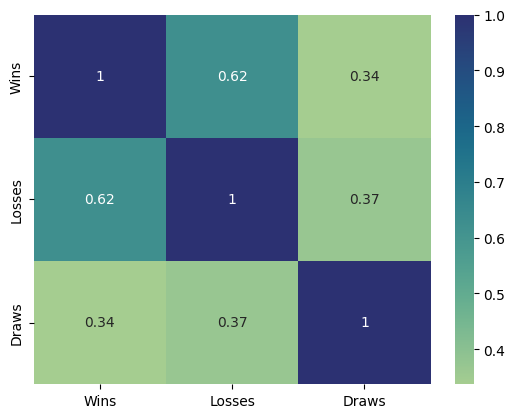

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt

df2 =df[["Wins","Losses","Draws"]] #seleccionamos las variables numéricas relevantes
corr =df2.corr() #creamos la matriz de correlacion respecto las 3 variables.

sns.heatmap(corr, annot=True,  cmap="crest") #generacion del heatmap con la matriz de correlacion
plt.show()

#se ha añadido la variable empates junto a las otras dos variables wins y losses
#se realiza un heatmap de la matriz de correlación ya que permite visualizar de forma rápida la correlacion entre las variables numéricas.
#revisamos la correlacion de draws respecto las otras dos variables. Podemos comprobar que es muy parecida pero ligeramente superior en Losses.
#todas las variables están correlacionadas ya que dependen del total de combates.


**Conclusiones: resume los principales hallazgos del análisis.**



1.   ¿Hay patrones interesantes en los datos?
2.   ¿Hay algún dato que te llame la atención o que necesite más investigación?



Hay cierto patrones interesantes que se pueden sacar del análisis. Hay cierta relación entre las victorias y derrotas (R^2 =0.39). Puede indicar que los luchadores con más victorias tienden también acumular más derrotas. Hay que tener en cuenta que ambas variables dependen del total de combates así que hay que cogerlo con pinzas.
Con el heatmap podemos comprobar cierta correlación entre las 3 variables wins, losees y draws. Las 3 presentan correlacion positiva y refuerza la idea de que el total de combates es redundante entre las variables.

Habría que hacer un análisis más en profundidad de los outliers y otro tipo de variables como podrían ser el peso, talla etc para poder catalogar los luchadores y compararlos por sus cualidades fisicas o técnicas.
